In [33]:
from huggingface_hub import notebook_login
notebook_login()


In [34]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
from datasets import load_dataset
import matplotlib.pyplot as plt
import random


RANDOM_SEED = 42

def seed_everything(seed=42):
    random.seed(seed) 
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

splits = {'train': 'train.csv', 'validation': 'dev.csv', 'test': 'test.csv'}

train_df = pd.read_csv("hf://datasets/uitnlp/vihsd/" + splits["train"])
drop_idx = train_df[train_df["label_id"] == 0].index[2000:]
train_df = train_df.drop(drop_idx)
train_df = train_df.reset_index()

test_df = pd.read_csv("hf://datasets/uitnlp/vihsd/" + splits["validation"])

train_df

,index,free_text,label_id
0,0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,2,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2
4,4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0
...,...,...,...
6157,24013,"Công nghệ của cs đã đạt mức thượng thừa rồi, c...",2
6158,24016,Corona ăn mất cái ý thức của chị rồi hả chị ơi :),2
6159,24027,Đéo thấy thằng nào bị tử hình... vì các nghìn ...,1
6160,24029,Mất hình tượng vl,1


# EDA

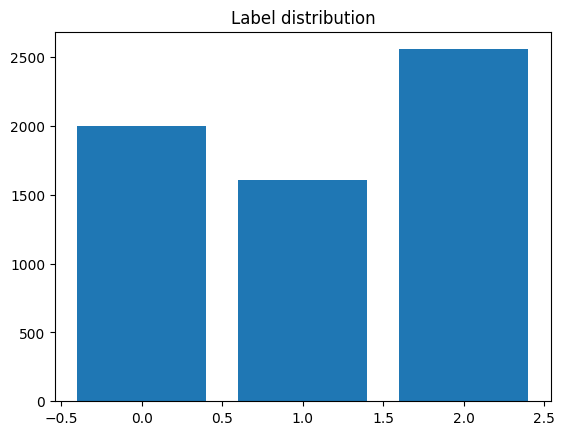

In [35]:
labels = [0, 1, 2]
label_cnt = [train_df[train_df["label_id"] == labels[i]].shape[0] for i in labels]

plt.title("Label distribution")
plt.bar(labels, label_cnt)
plt.show()

In [36]:
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm import tqdm

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len
        self.tokenizer = tokenizer
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tokens = self.tokenizer(str(self.texts[idx]), padding="max_length", truncation=True, max_length=self.max_len, return_tensors="pt")
        label = self.labels[idx]
        label = torch.tensor(label, dtype=torch.long)

        
        return{
            'input_ids': tokens['input_ids'].flatten(),
            'attention_mask': tokens['attention_mask'].flatten(),
            'labels': label
        }

BATCH_SIZE = 64
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
train_ds = ToxicDataset(train_df["free_text"], train_df["label_id"], tokenizer)
train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True, num_workers=4, pin_memory=True)
test_ds = ToxicDataset(test_df["free_text"], test_df["label_id"], tokenizer)
test_loader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle = False, num_workers=4, pin_memory=True)

for batch_idx, batch_data in enumerate(train_loader):
    # i is the batch index (0, 1, 2, ...)
    # inputs is the batch of features
    # targets is the batch of labels
    
    print(f"Batch {batch_idx} loaded with input shape: {batch_data["input_ids"].shape}")
    break



class ToxicClassifier(nn.Module):
    def __init__(self, hidden_size=512):
        super().__init__()
        self.pho_bert = AutoModel.from_pretrained("vinai/phobert-base")
        
        for name, param in self.pho_bert.named_parameters():
            if "encoder.layer.10" in name or "encoder.layer.11" in name or "pooler" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, 3)
        )

    def forward(self, inp, atn_msk):
        x = self.pho_bert(input_ids=inp, attention_mask=atn_msk)
        x = self.classifier(x.last_hidden_state[:, 0, :])
        return x



Batch 0 loaded with input shape: torch.Size([64, 256])


In [37]:
from sklearn.metrics import precision_recall_fscore_support

model = ToxicClassifier()


EPOCHS = 5
LR = 0.0001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(DEVICE)

best_f1 = 0

#For later visualization
all_f1 = []
all_recall= []
all_precision = []
all_train_loss = []
all_val_loss = []

for epoch in range(EPOCHS):
    model.train()

    train_total_loss = 0
    progress_bar = tqdm(train_loader, desc="Training:")
    for batch in progress_bar:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        logits = model(inp=input_ids, atn_msk=attention_mask)
        
        loss = criterion(logits.view(-1, 3), labels.view(-1))
        loss.backward()
        optimizer.step()

        train_total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})


    val_total_loss = 0
    val_correct_cnt = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating: "):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            logits = model(inp=input_ids, atn_msk=attention_mask)
            preds = torch.argmax(logits.view(-1, 3), dim = -1)
            val_correct_cnt += (preds == labels).sum().item()

            val_total_loss += criterion(logits.view(-1, 3), labels.view(-1))

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

            
    val_accuracy = val_correct_cnt / len(test_df)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    
    print(f"EPOCHS {epoch+1}: Train Loss = {train_total_loss / len(train_df) :.4f}  ;  Val Loss = {val_total_loss / len(test_df) :.4f}  ; Val Acc = {val_accuracy}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    #Saving for later visualization
    all_train_loss.append(train_total_loss / len(train_df))
    all_val_loss.append(val_total_loss / len(test_df))
    all_f1.append(f1)
    all_recall.append(recall)
    all_precision.append(precision)

    
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved best model!")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Evaluating: 100%|██████████| 42/42 [00:43<00:00,  1.04s/it]


EPOCHS 1: Train Loss = 0.0147  ;  Val Loss = 0.0155  ; Val Acc = 0.5681137724550899
Precision: 0.8278
Recall: 0.5681
F1-Score: 0.6331
Saved best model!


Evaluating: 100%|██████████| 42/42 [00:44<00:00,  1.05s/it]


EPOCHS 2: Train Loss = 0.0129  ;  Val Loss = 0.0105  ; Val Acc = 0.7365269461077845
Precision: 0.8179
Recall: 0.7365
F1-Score: 0.7631
Saved best model!


...

EPOCHS 3: Train Loss = 0.0120  ;  Val Loss = 0.0124  ; Val Acc = 0.6676646706586826
Precision: 0.8320
Recall: 0.6677
F1-Score: 0.7170


Evaluating: 100%|██████████| 42/42 [00:44<00:00,  1.05s/it]


EPOCHS 4: Train Loss = 0.0112  ;  Val Loss = 0.0132  ; Val Acc = 0.6384730538922155
Precision: 0.8242
Recall: 0.6385
F1-Score: 0.6915


Evaluating:  38%|███▊      | 16/42 [00:18<00:29,  1.13s/it]


KeyboardInterrupt: 

# Visualization

[tensor(0.0155), tensor(0.0105), tensor(0.0124), tensor(0.0132)]


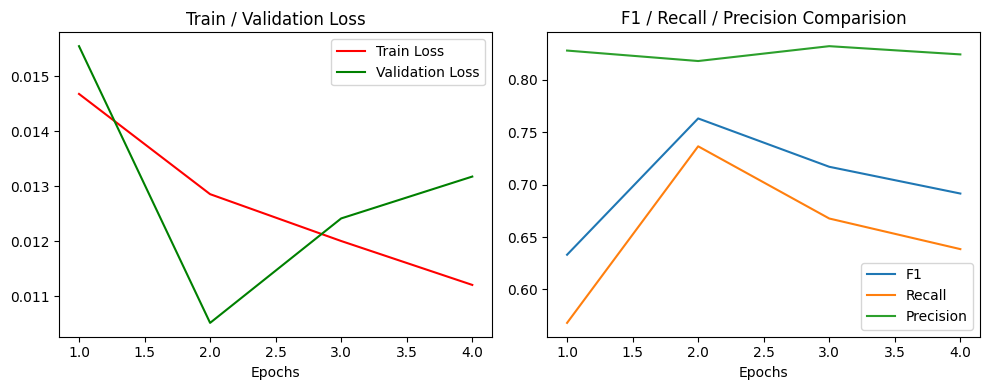

In [39]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
num_epochs = np.arange(1, EPOCHS)

all_val_loss = [i.cpu() for i in all_val_loss]
print(all_val_loss)

# First subplot (Left)
ax[0].plot(num_epochs, all_train_loss, color='red', label="Train Loss")
ax[0].plot(num_epochs, all_val_loss, color='green', label="Validation Loss")
ax[0].set_title('Train / Validation Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

# Second subplot (Right)
ax[1].set_title('F1 / Recall / Precision Comparision')
ax[1].plot(num_epochs, all_f1, label="F1")
ax[1].plot(num_epochs, all_recall, label="Recall")
ax[1].plot(num_epochs, all_precision, label="Precision")
ax[1].set_xlabel('Epochs')
ax[1].legend()


# Optimize padding between graphs
plt.tight_layout()
plt.show()